| Deep Learning | Project 4|
|---------------|----------|
| Sia | Tedy |
| Transformers | IMDB Sentiment|

# Project 4
## Transformer Models for Sequence Understanding

This notebook answers all conceptual questions, prepares the **IMDB Sentiment** dataset, implements a Transformer-based text classifier from scratch in PyTorch, trains and evaluates it, and visualizes attention patterns.

## Part 1 - Conceptual Questions (3%)

**1. What problem do Transformers solve compared to RNNs and LSTMs?**  
Transformers remove the strictly sequential processing of RNNs and LSTMs. Because they process all tokens in parallel, training is faster and they handle long-range dependencies better without repeatedly passing information through many time steps.

**2. What is self-attention?**  
Self-attention is a mechanism where each token compares itself with all other tokens in the same sequence and decides which ones are most relevant. This allows the model to build context-aware representations for every word.

**3. Why is positional encoding necessary?**  
A Transformer has no built-in sense of word order. Positional encoding injects information about token positions so the model can distinguish sequences like "Man hunts the lion" from "Lion hunts the man".

**4. What is the purpose of multi-head attention?**  
Multi-head attention lets the model learn different types of relationships at the same time. One head may focus on sentiment words, another on negation, and another on long-distance dependencies, which makes the representation richer.

## Part 2 - Dataset Preparation (3%)

We use the **IMDB Sentiment** dataset. The pipeline below:

- loads the dataset,
- creates train / validation / test splits,
- tokenizes and numericalizes text,
- pads sequences to a fixed length,
- builds PyTorch dataloaders,
- shows example tokenized sequences.

A small optional subset is used by default to keep training practical on a CPU. You can set the subset sizes to `None` if you want to train on the full IMDB dataset.

In [1]:
import math
import random
import re
from collections import Counter

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset


# Set random seeds so the results are more reproducible.
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Choose GPU if it is available, otherwise use CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Basic data and training hyperparameters.
MAX_VOCAB_SIZE = 20_000
MAX_SEQ_LEN = 256
BATCH_SIZE = 64
EMBED_DIM = 128
NUM_HEADS = 4
FFN_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.2
NUM_CLASSES = 2
LEARNING_RATE = 1e-3
NUM_EPOCHS = 5

# Use subsets by default so the notebook trains in a reasonable time.
MAX_TRAIN_SAMPLES = 10_000
MAX_VAL_SAMPLES = 2_500
MAX_TEST_SAMPLES = 2_500

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
pad_idx = 0
unk_idx = 1


def simple_tokenize(text):
    """Lowercase the text and keep only word-like tokens."""
    text = text.lower()
    return re.findall(r"\b\w+\b", text)


def build_vocab(texts, max_vocab_size=MAX_VOCAB_SIZE):
    """Build a vocabulary from the training set only to avoid data leakage."""
    counter = Counter()
    for text in texts:
        counter.update(simple_tokenize(text))

    most_common_tokens = counter.most_common(max_vocab_size - 2)
    stoi = {PAD_TOKEN: pad_idx, UNK_TOKEN: unk_idx}
    for token, _ in most_common_tokens:
        stoi[token] = len(stoi)
    itos = {idx: token for token, idx in stoi.items()}
    return stoi, itos


def numericalize(text, stoi, max_len=MAX_SEQ_LEN):
    """Convert tokens to ids and truncate long reviews."""
    tokens = simple_tokenize(text)
    token_ids = [stoi.get(token, unk_idx) for token in tokens][:max_len]
    return tokens[:max_len], token_ids


def pad_sequence(token_ids, max_len=MAX_SEQ_LEN):
    """Pad short sequences to a fixed length for batching."""
    attention_mask = [1] * len(token_ids)
    if len(token_ids) < max_len:
        padding_needed = max_len - len(token_ids)
        token_ids = token_ids + [pad_idx] * padding_needed
        attention_mask = attention_mask + [0] * padding_needed
    return token_ids, attention_mask


class TextDataset(Dataset):
    """A lightweight dataset wrapper for token ids, masks, and labels."""

    def __init__(self, texts, labels, stoi):
        self.samples = []
        for text, label in zip(texts, labels):
            tokens, token_ids = numericalize(text, stoi)
            padded_ids, attention_mask = pad_sequence(token_ids)
            self.samples.append(
                {
                    "raw_text": text,
                    "tokens": tokens,
                    "input_ids": torch.tensor(padded_ids, dtype=torch.long),
                    "attention_mask": torch.tensor(attention_mask, dtype=torch.bool),
                    "label": torch.tensor(label, dtype=torch.long),
                }
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate_batch(batch):
    """Combine a list of samples into one mini-batch."""
    input_ids = torch.stack([item["input_ids"] for item in batch])
    attention_mask = torch.stack([item["attention_mask"] for item in batch])
    labels = torch.stack([item["label"] for item in batch])
    raw_texts = [item["raw_text"] for item in batch]
    tokens = [item["tokens"] for item in batch]
    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
        "raw_texts": raw_texts,
        "tokens": tokens,
    }


# Load IMDB and split the original training split into train and validation.
dataset = load_dataset("imdb")
split_dataset = dataset["train"].train_test_split(test_size=0.2, seed=SEED)

train_split = split_dataset["train"]
val_split = split_dataset["test"]
test_split = dataset["test"]

# Optional subset selection for faster experiments.
if MAX_TRAIN_SAMPLES is not None:
    train_split = train_split.select(range(min(MAX_TRAIN_SAMPLES, len(train_split))))
if MAX_VAL_SAMPLES is not None:
    val_split = val_split.select(range(min(MAX_VAL_SAMPLES, len(val_split))))
if MAX_TEST_SAMPLES is not None:
    test_split = test_split.select(range(min(MAX_TEST_SAMPLES, len(test_split))))

train_texts = train_split["text"]
train_labels = train_split["label"]
val_texts = val_split["text"]
val_labels = val_split["label"]
test_texts = test_split["text"]
test_labels = test_split["label"]

# Build the vocabulary using only training texts.
stoi, itos = build_vocab(train_texts)
vocab_size = len(stoi)

# Create dataset objects and dataloaders.
train_dataset = TextDataset(train_texts, train_labels, stoi)
val_dataset = TextDataset(val_texts, val_labels, stoi)
test_dataset = TextDataset(test_texts, test_labels, stoi)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Vocabulary size: {vocab_size}")

# Show an example tokenized review.
example_index = 0
example_tokens, example_ids = numericalize(train_texts[example_index], stoi)
print("\nExample raw review snippet:")
print(train_texts[example_index][:300], "...")
print("\nExample tokens:")
print(example_tokens[:30])
print("\nExample token ids:")
print(example_ids[:30])

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train samples: 10000
Validation samples: 2500
Test samples: 2500
Vocabulary size: 20000

Example raw review snippet:
Stage adaptations often have a major fault. They often come out looking like a film camera was simply placed on the stage (Such as "Night Mother"). Sidney Lumet's direction keeps the film alive, which is especially difficult since the picture offered him no real challenge. Still, it's nice to look a ...

Example tokens:
['stage', 'adaptations', 'often', 'have', 'a', 'major', 'fault', 'they', 'often', 'come', 'out', 'looking', 'like', 'a', 'film', 'camera', 'was', 'simply', 'placed', 'on', 'the', 'stage', 'such', 'as', 'night', 'mother', 'sidney', 'lumet', 's', 'direction']

Example token ids:
[796, 4545, 395, 29, 4, 673, 1769, 34, 395, 221, 46, 276, 40, 4, 21, 359, 15, 332, 2571, 24, 2, 796, 139, 16, 305, 419, 2572, 3992, 14, 468]


## Part 3 - Implement a Transformer Model (7%)

The classifier below is built from core PyTorch layers instead of using a ready-made HuggingFace classifier. It contains:

- an **embedding layer**,
- a **sinusoidal positional encoding**,
- stacked **Transformer encoder blocks**,
- a **classification head**.

Key architectural choices used in this notebook:

- **Number of heads = 4**: each head can focus on a different relationship between words.
- **Hidden dimension = 128**: this is the size of each token representation.
- **Number of layers = 2**: deep enough to learn meaningful interactions, but still lightweight for a class project.

In [2]:
class PositionalEncoding(nn.Module):
    """Add deterministic position information to token embeddings."""

    def __init__(self, embed_dim, max_len=MAX_SEQ_LEN):
        super().__init__()

        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2) * (-math.log(10000.0) / embed_dim))
        pe = torch.zeros(max_len, embed_dim)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Register the tensor as a buffer so it moves with the model but is not trained.
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]


class TransformerEncoderBlock(nn.Module):
    """One encoder block with multi-head self-attention and a feed-forward network."""

    def __init__(self, embed_dim, num_heads, ffn_dim, dropout=0.1):
        super().__init__()

        # Multi-head attention lets the model inspect several interaction patterns at once.
        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        # The feed-forward network increases non-linearity after attention mixes information.
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ffn_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, embed_dim),
        )

        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.last_attention_weights = None

    def forward(self, x, padding_mask):
        # key_padding_mask expects True for padded tokens, so we invert the valid-token mask.
        key_padding_mask = ~padding_mask

        attn_output, attn_weights = self.attention(
            query=x,
            key=x,
            value=x,
            key_padding_mask=key_padding_mask,
            need_weights=True,
            average_attn_weights=False,
        )

        # Save attention weights so we can visualize them later.
        self.last_attention_weights = attn_weights.detach().cpu()

        x = self.norm1(x + self.dropout(attn_output))
        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_output))
        return x


class TransformerClassifier(nn.Module):
    """A simple Transformer encoder model for sentiment classification."""

    def __init__(self, vocab_size, embed_dim, num_heads, ffn_dim, num_layers, num_classes, dropout=0.1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.position_encoding = PositionalEncoding(embed_dim)
        self.dropout = nn.Dropout(dropout)

        # We stack several encoder layers so the model can refine token interactions gradually.
        self.layers = nn.ModuleList(
            [TransformerEncoderBlock(embed_dim, num_heads, ffn_dim, dropout) for _ in range(num_layers)]
        )

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        # Convert token ids into dense vectors.
        x = self.embedding(input_ids)

        # Scale embeddings before adding positional encoding, which is a common Transformer trick.
        x = x * math.sqrt(x.size(-1))
        x = self.position_encoding(x)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x, attention_mask)

        # Mean pooling over only the real tokens gives one vector for the full review.
        mask = attention_mask.unsqueeze(-1)
        masked_x = x * mask
        pooled = masked_x.sum(dim=1) / mask.sum(dim=1).clamp(min=1)

        logits = self.classifier(pooled)
        return logits


model = TransformerClassifier(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ffn_dim=FFN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

TransformerClassifier(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (position_encoding): PositionalEncoding()
  (dropout): Dropout(p=0.2, inplace=False)
  (layers): ModuleList(
    (0-1): 2 x TransformerEncoderBlock(
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (ffn): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.2, inplace=False)
        (3): Linear(in_features=256, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.2, inplace=False)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
 

## Part 4 - Training and Evaluation (4%)

The next cell trains the Transformer classifier, tracks training loss and validation accuracy, evaluates the final model on the test set, and plots the learning curves.

Epoch 1/5 | Train Loss: 0.6167 | Train Acc: 0.6493 | Val Loss: 0.5163 | Val Acc: 0.7456
Epoch 2/5 | Train Loss: 0.5367 | Train Acc: 0.7301 | Val Loss: 0.5388 | Val Acc: 0.7408
Epoch 3/5 | Train Loss: 0.4877 | Train Acc: 0.7647 | Val Loss: 0.4662 | Val Acc: 0.7784
Epoch 4/5 | Train Loss: 0.4529 | Train Acc: 0.7889 | Val Loss: 0.4486 | Val Acc: 0.7884
Epoch 5/5 | Train Loss: 0.4281 | Train Acc: 0.8012 | Val Loss: 0.4462 | Val Acc: 0.7956

Final Results
Best Validation Accuracy: 0.7956
Final Test Accuracy: 0.8652


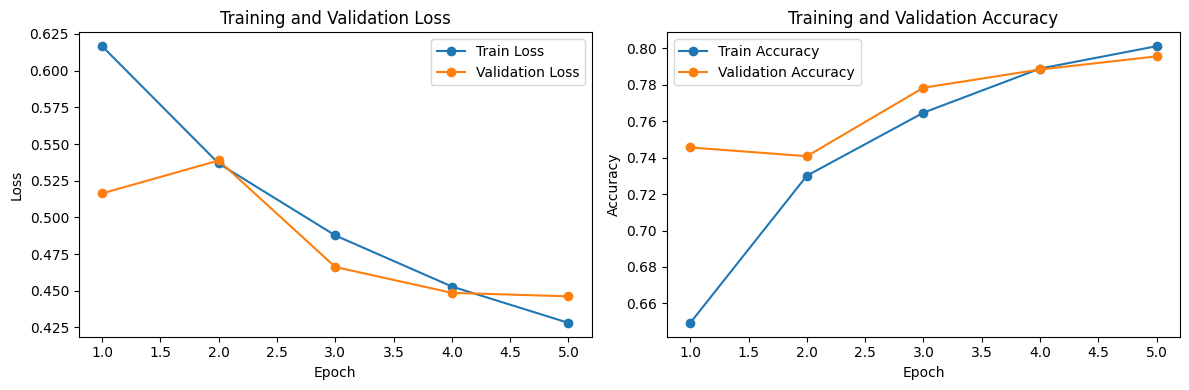

In [3]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * input_ids.size(0)
        predictions = logits.argmax(dim=1)
        total_correct += (predictions == labels).sum().item()
        total_examples += labels.size(0)

    avg_loss = total_loss / total_examples
    avg_accuracy = total_correct / total_examples
    return avg_loss, avg_accuracy


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        total_loss += loss.item() * input_ids.size(0)
        predictions = logits.argmax(dim=1)
        total_correct += (predictions == labels).sum().item()
        total_examples += labels.size(0)

    avg_loss = total_loss / total_examples
    avg_accuracy = total_correct / total_examples
    return avg_loss, avg_accuracy


history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc = 0.0
best_state_dict = None

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print("\nFinal Results")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")

# Plot learning curves to show how training evolves over time.
epochs = range(1, NUM_EPOCHS + 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(epochs, history["val_acc"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Part 5 - Attention Visualization (2%)

The cell below runs one sample review through the model, extracts the attention weights from the first encoder layer, and visualizes one attention head as a heatmap.

Sample review snippet:
I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn't match the background, and painfully one-dimensional characters cannot be overcome wit ...

True label: negative
Predicted label: negative
Class probabilities: negative=0.9356, positive=0.0644


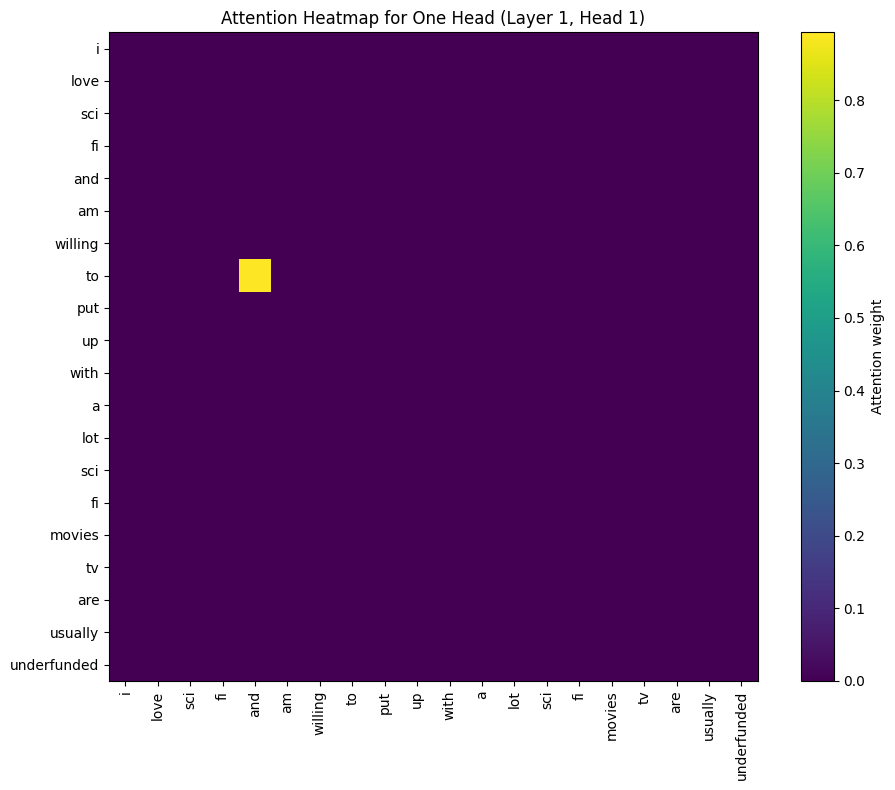

In [4]:
@torch.no_grad()
def predict_single_text(model, text, stoi, device):
    model.eval()
    tokens, token_ids = numericalize(text, stoi)
    padded_ids, attention_mask = pad_sequence(token_ids)

    input_ids = torch.tensor([padded_ids], dtype=torch.long).to(device)
    attention_mask_tensor = torch.tensor([attention_mask], dtype=torch.bool).to(device)

    logits = model(input_ids, attention_mask_tensor)
    prediction = logits.argmax(dim=1).item()
    probabilities = torch.softmax(logits, dim=1).squeeze(0).cpu()
    return tokens, prediction, probabilities


# Pick one example from the test set.
sample_text = test_texts[0]
sample_label = test_labels[0]

tokens, prediction, probabilities = predict_single_text(model, sample_text, stoi, device)

# Retrieve attention from the first encoder layer.
attention_weights = model.layers[0].last_attention_weights

# attention_weights shape: [batch_size, num_heads, seq_len, seq_len]
head_index = 0
valid_len = len(tokens)
attention_map = attention_weights[0, head_index, :valid_len, :valid_len]

label_names = {0: "negative", 1: "positive"}

print("Sample review snippet:")
print(sample_text[:400], "...")
print()
print(f"True label: {label_names[sample_label]}")
print(f"Predicted label: {label_names[prediction]}")
print(f"Class probabilities: negative={probabilities[0]:.4f}, positive={probabilities[1]:.4f}")

# Limit the plot to the first 20 tokens so it remains readable.
plot_tokens = tokens[:20]
plot_attention = attention_map[:20, :20]

plt.figure(figsize=(10, 8))
plt.imshow(plot_attention, cmap="viridis")
plt.colorbar(label="Attention weight")
plt.xticks(range(len(plot_tokens)), plot_tokens, rotation=90)
plt.yticks(range(len(plot_tokens)), plot_tokens)
plt.title("Attention Heatmap for One Head (Layer 1, Head 1)")
plt.tight_layout()
plt.show()

### Attention Discussion

In sentiment classification, attention often becomes strong around emotionally important words such as **great**, **terrible**, **boring**, **excellent**, or around negation words like **not** and **never**. If the model is working well, the heatmap should show that some tokens attend strongly to sentiment-bearing terms and nearby context, because those words are most useful for deciding whether the review is positive or negative.

## Part 6 - Reflection (1%)

**Advantages of Transformers**  
Transformers capture long-range dependencies more effectively than recurrent models and allow parallel computation across tokens, which makes training more efficient. Multi-head attention also gives the model a flexible way to learn several types of linguistic relationships at once.

**Challenges encountered during training**  
Training Transformers can be computationally expensive, especially with long reviews and large vocabularies. Another challenge is choosing practical hyperparameters so the model trains fast enough for a course notebook while still reaching useful accuracy.